<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/ComputerVision-Project/blob/main/CPV301.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!gdown 1QAXardZbIByfehzshQvbw4ByxiTC1ztU
!gdown 1DpKi1rgqHgAEAA0Cx2RWZs_7yWv5bv2T
!gdown 1DYO_g9_NPjwVOxXNZ4upEWjfHBm4byqU

Downloading...
From: https://drive.google.com/uc?id=1QAXardZbIByfehzshQvbw4ByxiTC1ztU
To: /content/Object.png
100% 51.0k/51.0k [00:00<00:00, 72.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DpKi1rgqHgAEAA0Cx2RWZs_7yWv5bv2T
To: /content/GreenBackground.png
100% 5.51k/5.51k [00:00<00:00, 13.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1DYO_g9_NPjwVOxXNZ4upEWjfHBm4byqU
To: /content/NewBackground.jpg
100% 64.3k/64.3k [00:00<00:00, 76.8MB/s]


In [ ]:
!gdown 1KAZQVg40mG0vuEdC4HbjkDdms_brf2bW
!gdown 1YF4WkCaaGYd2Zm-PNoLa2A2tFf3e64ci

Downloading...
From: https://drive.google.com/uc?id=1KAZQVg40mG0vuEdC4HbjkDdms_brf2bW
To: /content/dog.jpeg
100% 33.7k/33.7k [00:00<00:00, 54.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1YF4WkCaaGYd2Zm-PNoLa2A2tFf3e64ci
To: /content/advertising.csv
100% 4.06k/4.06k [00:00<00:00, 12.1MB/s]


## Resize các ảnh đầu vào về cùng kích thước

In [ ]:
import numpy as np
from google.colab.patches import cv2_imshow
import cv2

bg1_image = cv2.imread("GreenBackground.png", 1)
bg1_image = cv2.resize(bg1_image, (678, 381))

ob_image = cv2.imread("Object.png", 1)
ob_image = cv2.resize(ob_image, (678, 381))

bg2_image = cv2.imread("NewBackground.jpg", 1)
bg2_image = cv2.resize(bg2_image, (678, 381))

## Xây dựng hàm compute_difference():

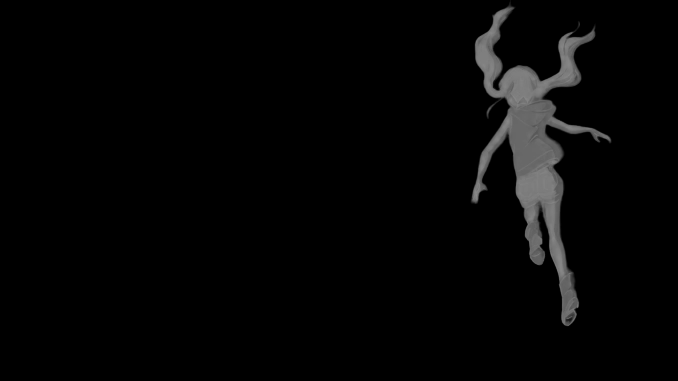

In [ ]:
def compute_difference(bg_img, input_img):
  # Tính toán sự khác biệt tuyệt đối giữa hai ảnh
  difference_three_channel = cv2.absdiff(bg_img, input_img)

  # Chuyển đổi sang ảnh xám (single channel)
  difference_single_channel = cv2.cvtColor(difference_three_channel, cv2.COLOR_BGR2GRAY)

  return difference_single_channel

# Kiểm tra thử hàm với các ảnh đã load
difference_image = compute_difference(bg1_image, ob_image)
cv2_imshow(difference_image)

## Xây dựng hàm compute_binary_mask():

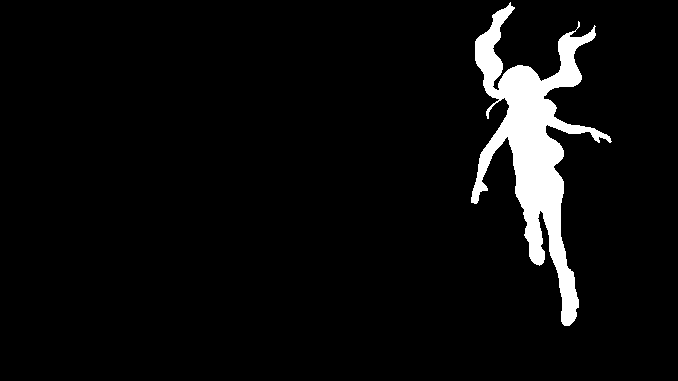

In [ ]:
def compute_binary_mask(difference_single_channel):
    # Phân ngưỡng: nếu giá trị >= 15 thì thành 255, ngược lại thành 0
    mask = np.where(difference_single_channel >= 15, 255, 0)

    # Chuyển từ 1 kênh thành 3 kênh bằng cách xếp chồng (stack)
    # (mask,)*3 tạo ra một tuple chứa 3 mảng mask giống hệt nhau
    binary_mask = np.stack((mask,)*3, axis=-1)

    # Chuyển kiểu dữ liệu về uint8
    binary_mask = binary_mask.astype(np.uint8)

    return binary_mask

# Kiểm tra thử hàm
binary_mask = compute_binary_mask(difference_image)
cv2_imshow(binary_mask)

## Xây dựng hàm replace_background():

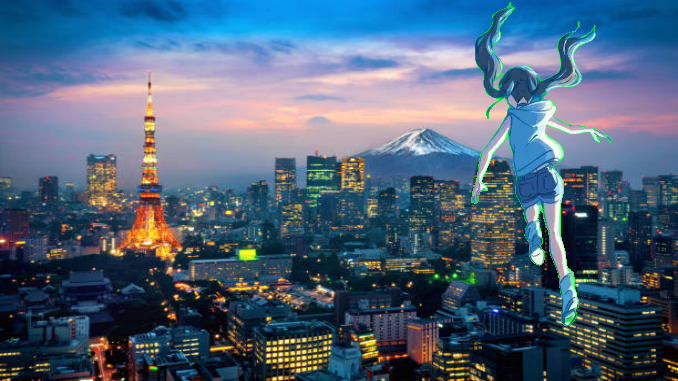

In [ ]:
def replace_background(bg1_image, bg2_image, ob_image):
  difference_single_channel = compute_difference(
      bg1_image,
      ob_image
    )

  binary_mask = compute_binary_mask(difference_single_channel)

  # Nếu mask là 255 (đối tượng), lấy từ ob_image. Nếu là 0 (nền), lấy từ bg2_image
  output = np.where(binary_mask==255, ob_image, bg2_image)

  return output

# Gọi hàm và hiển thị kết quả
final_result = replace_background(bg1_image, bg2_image, ob_image)
cv2_imshow(final_result)

## Tải và đọc ảnh

In [ ]:
import matplotlib.image as mpimg
import numpy as np
img = mpimg.imread("/content/dog.jpeg")

## Lightness

In [ ]:
# ======== Your code here ===========
# Sử dụng công thức Lightness: (max(R,G,B) + min(R,G,B))/2

# Lấy giá trị max và min dọc theo trục color (axis=2)
max_rgb = np.max(img, axis=2)
min_rgb = np.min(img, axis=2)

# Áp dụng công thức Lightness
gray_img_01 = (max_rgb.astype(float) + min_rgb.astype(float)) / 2

# Chuyển về kiểu int để in ra đẹp hơn hoặc uint8 nếu muốn hiển thị
print(gray_img_01[0, 0])

102.5


## Average

In [ ]:
# ========= Your code here ==========
# Sử dụng công thức Average: (R+G+B)/3
gray_img_02 = np.mean(img, axis=2)

print(gray_img_02[0, 0])

107.66666666666667


## Luminosity

In [ ]:
# ============= Your code here =============
# Sử dụng công thức Luminosity: 0.21*R + 0.72*G + 0.07*B

# img[:, :, 0] là kênh Red, [:, :, 1] là Green, [:, :, 2] là Blue
gray_img_03 = 0.21 * img[:, :, 0] + 0.72 * img[:, :, 1] + 0.07 * img[:, :, 2]

print(gray_img_03[0, 0])

126.22999999999999


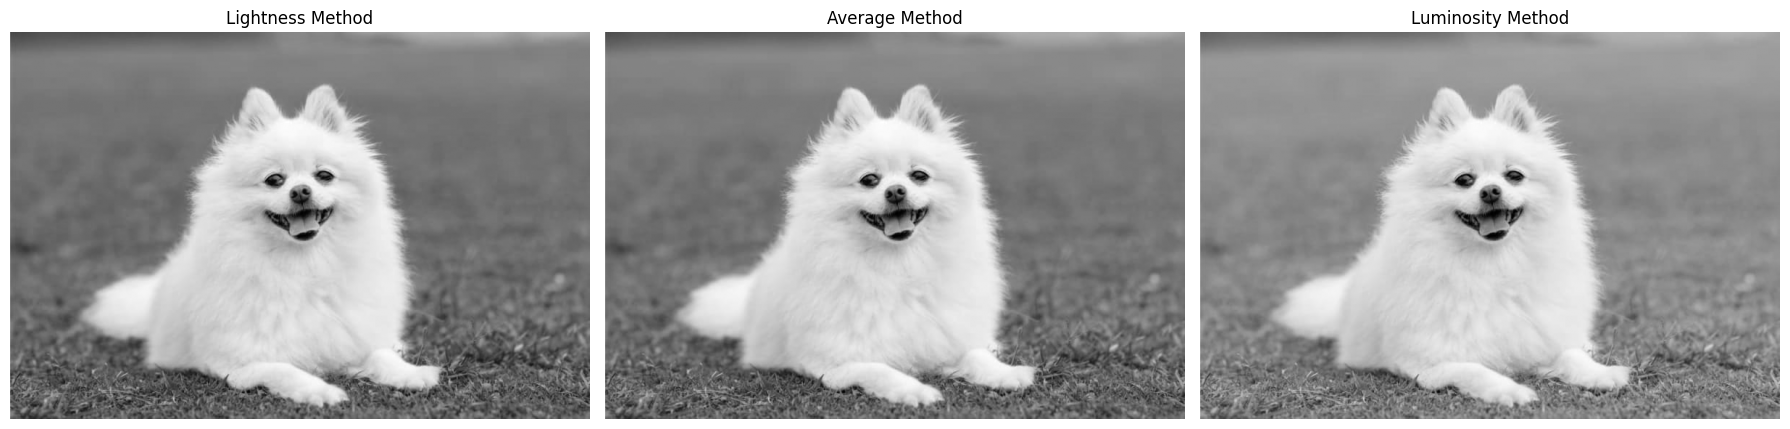

In [ ]:
import matplotlib.pyplot as plt

# Thiết lập kích thước hiển thị
plt.figure(figsize=(18, 6))

# Hiển thị ảnh phương pháp Lightness
plt.subplot(1, 3, 1)
plt.imshow(gray_img_01, cmap='gray')
plt.title('Lightness Method')
plt.axis('off')

# Hiển thị ảnh phương pháp Average
plt.subplot(1, 3, 2)
plt.imshow(gray_img_02, cmap='gray')
plt.title('Average Method')
plt.axis('off')

# Hiển thị ảnh phương pháp Luminosity
plt.subplot(1, 3, 3)
plt.imshow(gray_img_03, cmap='gray')
plt.title('Luminosity Method')
plt.axis('off')

plt.tight_layout()
plt.show()

## Tìm giá trị lớn nhất cột Sales

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/advertising.csv")
data = df.to_numpy()
sales = data[:, -1]
max_value = np.max(sales)
max_index = np.argmax(sales)
print(f"Max: {max_value} - Index: {max_index}")

Max: 27.0 - Index: 175


## Tính trung bình cột TV

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/advertising.csv")
data = df.to_numpy()
tv = data[:, 0]
mean_tv = np.mean(tv)
print(mean_tv)

147.0425


## Trung bình Radio với điều kiện Sales >= 15

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/advertising.csv")
data = df.to_numpy()
sales = data[:, -1]
radio = data[:, 1]
mean_radio = np.mean(radio[sales >= 15])
print(mean_radio)

26.22293577981651


## Tổng Sales với điều kiện Newspaper > trung bình

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("/content/advertising.csv")
data = df.to_numpy()
sales = data[:, -1]
newspaper = data[:, 2]
mean_newspaper = np.mean(newspaper)
sum_sales = np.sum(sales[newspaper > mean_newspaper])
print(sum_sales)

1405.1
